# Regressão Linear com Enfoque Bayesiano
## *Combined Cycle Power Plant*

**Disciplina:** Estatística Bayesiana

---

## Introdução

Neste trabalho, será utilizada uma abordagem de **regressão linear bayesiana** para modelar a relação entre variáveis ambientais e a produção líquida horária de energia elétrica, medida em megawatts (MW). Para isso, emprega-se o conjunto de dados *Combined Cycle Power Plant*, disponibilizado pela *UCI Machine Learning Repository*. O banco contém $n = 9568$ observações coletadas ao longo de seis anos (2006–2011), durante períodos em que a usina operou sob carga total. As observações correspondem a médias horárias obtidas por sensores instalados no sistema de geração.

A variável resposta considerada neste estudo é a potência elétrica líquida produzida (`PE`), expressa em MW. Como variáveis explicativas são utilizadas quatro medidas ambientais contínuas:

| Variável | Descrição | Unidade |
|---|---|---|
| `AT` | Temperatura ambiente | °C |
| `V`  | Vácuo de exaustão | cm Hg |
| `AP` | Pressão atmosférica | mbar |
| `RH` | Umidade relativa do ar | % |
| `PE` | Potência elétrica líquida **(resposta)** | MW |

Diferentemente da regressão linear sob a abordagem clássica, a **inferência bayesiana** trata os parâmetros do modelo como variáveis aleatórias e incorpora conhecimento prévio por meio de distribuições *a priori*. Especificamente, será adotado o modelo de regressão linear gaussiano com prior conjugado **Normal–Gama Inversa** para o par $(\boldsymbol{\beta}, \sigma^2)$. Essa escolha permite derivação analítica da distribuição posterior conjunta e fornece interpretação probabilística direta sobre os coeficientes de regressão e sobre a variabilidade residual do processo.

---
## 1. Conceito Teórico: Regressão Linear Bayesiana com Prior Normal–Gama Inversa

### 1.1 Modelo Generativo

Considere o modelo de regressão linear clássico:

$$\mathbf{Y} = X\boldsymbol{\beta} + \boldsymbol{\varepsilon}$$

onde $\mathbf{Y} \in \mathbb{R}^{n}$, $X \in \mathbb{R}^{n \times p}$, $\boldsymbol{\beta} \in \mathbb{R}^{p}$ e $\boldsymbol{\varepsilon} \sim \mathcal{N}_n(\mathbf{0}, \sigma^2 I_n)$.

Logo:

$$\mathbf{Y} \mid \boldsymbol{\beta}, \sigma^2 \sim \mathcal{N}_n(X\boldsymbol{\beta},\, \sigma^2 I_n)$$

A densidade da verossimilhança é:

$$p(\mathbf{Y} \mid \boldsymbol{\beta}, \sigma^2) = (2\pi\sigma^2)^{-n/2} \exp\!\left\{ -\frac{1}{2\sigma^2}(\mathbf{Y} - X\boldsymbol{\beta})^\top(\mathbf{Y} - X\boldsymbol{\beta}) \right\}$$

Ignorando constantes:

$$L(\boldsymbol{\beta}, \sigma^2) \propto (\sigma^2)^{-n/2} \exp\!\left( -\frac{(\mathbf{Y} - X\boldsymbol{\beta})^\top(\mathbf{Y} - X\boldsymbol{\beta})}{2\sigma^2} \right)$$

### 1.2 Especificação Bayesiana

Escolhemos o **prior conjugado**:

$$\sigma^2 \sim \text{IG}(a_0, b_0), \quad a_0 > 0,\; b_0 > 0$$

com densidade:

$$p(\sigma^2) = \frac{b_0^{a_0}}{\Gamma(a_0)}(\sigma^2)^{-a_0-1} \exp\!\left(-\frac{b_0}{\sigma^2}\right)$$

Condicionalmente a $\sigma^2$:

$$\boldsymbol{\beta} \mid \sigma^2 \sim \mathcal{N}_p\!\left(\boldsymbol{\mu}_0,\; \sigma^2 \Lambda_0^{-1}\right)$$

onde $\Lambda_0 \in \mathbb{R}^{p \times p}$ é simétrica definida positiva. Logo:

$$(\boldsymbol{\beta}, \sigma^2) \sim \text{NIG}(\boldsymbol{\mu}_0, \Lambda_0, a_0, b_0)$$

### 1.3 Aplicação do Teorema de Bayes

Pelo Teorema de Bayes:

$$p(\boldsymbol{\beta}, \sigma^2 \mid \mathbf{Y}) = \frac{p(\mathbf{Y} \mid \boldsymbol{\beta}, \sigma^2)\, p(\boldsymbol{\beta}, \sigma^2)}{p(\mathbf{Y})} \propto p(\mathbf{Y} \mid \boldsymbol{\beta}, \sigma^2)\, p(\boldsymbol{\beta}, \sigma^2)$$

Multiplicando verossimilhança × prior conjunto e agrupando as potências de $\sigma^2$:

$$p(\boldsymbol{\beta}, \sigma^2 \mid \mathbf{Y}) \propto (\sigma^2)^{-a_0 - 1 - n/2 - p/2} \exp\!\left[ -\frac{1}{\sigma^2}\left(b_0 + \frac{1}{2}(\mathbf{Y} - X\boldsymbol{\beta})^\top(\mathbf{Y} - X\boldsymbol{\beta}) + \frac{1}{2}(\boldsymbol{\beta} - \boldsymbol{\mu}_0)^\top \Lambda_0 (\boldsymbol{\beta} - \boldsymbol{\mu}_0)\right) \right]$$

### 1.4 Completando o Quadrado

Expandindo os termos quadráticos em $\boldsymbol{\beta}$ e somando:

$$\boldsymbol{\beta}^\top(X^\top X + \Lambda_0)\boldsymbol{\beta} - 2\boldsymbol{\beta}^\top(X^\top \mathbf{Y} + \Lambda_0 \boldsymbol{\mu}_0) + \mathbf{Y}^\top\mathbf{Y} + \boldsymbol{\mu}_0^\top\Lambda_0\boldsymbol{\mu}_0$$

Definindo os **parâmetros posteriores**:

$$\boxed{\Lambda_n = X^\top X + \Lambda_0}$$

$$\boxed{\boldsymbol{\mu}_n = \Lambda_n^{-1}(X^\top \mathbf{Y} + \Lambda_0 \boldsymbol{\mu}_0)}$$

e completando o quadrado:

$$(\boldsymbol{\beta} - \boldsymbol{\mu}_n)^\top \Lambda_n (\boldsymbol{\beta} - \boldsymbol{\mu}_n) + \mathbf{Y}^\top\mathbf{Y} + \boldsymbol{\mu}_0^\top\Lambda_0\boldsymbol{\mu}_0 - \boldsymbol{\mu}_n^\top\Lambda_n\boldsymbol{\mu}_n$$

### 1.5 Atualização dos Hiperparâmetros

Os parâmetros posteriores completos tornam-se:

$$\boxed{a_n = a_0 + \frac{n}{2}}$$

$$\boxed{b_n = b_0 + \frac{1}{2}\left(\mathbf{Y}^\top\mathbf{Y} + \boldsymbol{\mu}_0^\top\Lambda_0\boldsymbol{\mu}_0 - \boldsymbol{\mu}_n^\top\Lambda_n\boldsymbol{\mu}_n\right)}$$

### 1.6 Distribuição Posterior Conjunta

Concluímos:

$$(\boldsymbol{\beta}, \sigma^2 \mid \mathbf{Y}) \sim \text{NIG}(\boldsymbol{\mu}_n, \Lambda_n, a_n, b_n)$$

Equivalente à fatoração:

$$\sigma^2 \mid \mathbf{Y} \sim \text{IG}(a_n, b_n)$$

$$\boldsymbol{\beta} \mid \sigma^2, \mathbf{Y} \sim \mathcal{N}_p(\boldsymbol{\mu}_n,\; \sigma^2 \Lambda_n^{-1})$$

### 1.7 Interpretação Bayesiana

Os hiperparâmetros possuem interpretação direta:

- $\boldsymbol{\mu}_0$: média *a priori* dos coeficientes  
- $\Lambda_0$: precisão *a priori* (quanto mais concentrada a prior, maior $\Lambda_0$)  
- $a_0, b_0$: informação prévia sobre a variância residual

A atualização:

$$\boldsymbol{\mu}_n = (X^\top X + \Lambda_0)^{-1}(X^\top \mathbf{Y} + \Lambda_0 \boldsymbol{\mu}_0)$$

mostra explicitamente que a posterior é uma **média ponderada** entre os dados ($X^\top \mathbf{Y}$) e o conhecimento prévio ($\Lambda_0 \boldsymbol{\mu}_0$). No limite em que $\Lambda_0 \to 0$ (prior não-informativo), recupera-se a inferência clássica de mínimos quadrados ordinários.

---
## 2. Dados

O conjunto contém $n = 9568$ observações e $p = 5$ variáveis (4 covariáveis e 1 resposta), todas contínuas. Nenhuma observação apresenta dados faltantes.

A seguir, carregamos os dados e exibimos as 10 primeiras e as 10 últimas observações, na ordem original disponibilizada pelo UCI.

In [1]:
# Carregamento do pacote e leitura dos dados
# install.packages("readxl")  # descomente se necessário
library(readxl)

dados <- read_excel("Folds5x2_pp.xlsx")

cat("Dimensões do dataset:", nrow(dados), "observações ×", ncol(dados), "variáveis\n")
cat("Nomes das colunas:", paste(names(dados), collapse = ", "), "\n")

Dimensões do dataset: 9568 observações × 5 variáveis
Nomes das colunas: AT, V, AP, RH, PE 


In [2]:
# Primeiras 10 observações
cat("=== Primeiras 10 observações ===\n")
print(head(dados, 10))

cat("\n=== Últimas 10 observações ===\n")
print(tail(dados, 10))

=== Primeiras 10 observações ===
# A tibble: 10 × 5
      AT     V    AP    RH    PE
   <dbl> <dbl> <dbl> <dbl> <dbl>
 1 15.0   41.8 1024.  73.2  463.
 2 25.2   63.0 1020.  59.1  444.
 3  5.11  39.4 1012.  92.1  489.
 4 20.9   57.3 1010.  76.6  446.
 5 10.8   37.5 1009.  96.6  474.
 6 26.3   59.4 1012.  58.8  444.
 7 15.9   44.0 1014.  75.2  467.
 8  9.48  44.7 1019.  66.4  478.
 9 14.6   45   1022.  41.2  476.
10 11.7   43.6 1015.  70.7  478.

=== Últimas 10 observações ===
# A tibble: 10 × 5
      AT     V    AP    RH    PE
   <dbl> <dbl> <dbl> <dbl> <dbl>
 1  23.0  62.4 1010.  75.2  445.
 2  26.2  49.8 1015.  55.8  454.
 3  23.3  68.3 1005.  74.8  445.
 4  11.8  41.6 1021.  88.4  465.
 5  14.0  40.1 1016.  82.4  467.
 6  16.6  49.7 1014.  91    460.
 7  13.2  39.2 1024.  66.8  470.
 8  31.3  74.3 1013.  36.5  430.
 9  24.5  69.4 1014.  62.4  436.
10  21.6  62.5 1017.  67.9  453.


In [3]:
# Verificação de dados faltantes
cat("Valores ausentes por variável:\n")
print(colSums(is.na(dados)))

Valores ausentes por variável:
AT  V AP RH PE 
 0  0  0  0  0 


---
## 3. Análise Descritiva

Antes de ajustar o modelo, investigamos a distribuição marginal de cada variável e as correlações entre elas. Isso é fundamental para:

1. **Entender a escala** de cada covariável (importante na escolha de $\Lambda_0$);
2. **Identificar correlações** entre preditores (multicolinearidade);
3. **Verificar a relação linear** entre cada covariável e a resposta $PE$.

In [4]:
# Estatísticas descritivas resumidas
summary(dados)

       AT              V               AP               RH        
 Min.   : 1.81   Min.   :25.36   Min.   : 992.9   Min.   : 25.56  
 1st Qu.:13.51   1st Qu.:41.74   1st Qu.:1009.1   1st Qu.: 63.33  
 Median :20.34   Median :52.08   Median :1012.9   Median : 74.97  
 Mean   :19.65   Mean   :54.31   Mean   :1013.3   Mean   : 73.31  
 3rd Qu.:25.72   3rd Qu.:66.54   3rd Qu.:1017.3   3rd Qu.: 84.83  
 Max.   :37.11   Max.   :81.56   Max.   :1033.3   Max.   :100.16  
       PE       
 Min.   :420.3  
 1st Qu.:439.8  
 Median :451.6  
 Mean   :454.4  
 3rd Qu.:468.4  
 Max.   :495.8  

In [5]:
# Desvios-padrão e coeficientes de variação
dp <- sapply(dados, sd)
medias <- sapply(dados, mean)
cv <- dp / medias * 100

descr <- data.frame(
  Media  = round(medias, 3),
  DP     = round(dp, 3),
  CV_pct = round(cv, 2)
)
print(descr)

      Media     DP CV_pct
AT   19.651  7.452  37.92
V    54.306 12.708  23.40
AP 1013.259  5.939   0.59
RH   73.309 14.600  19.92
PE  454.365 17.067   3.76


In [6]:
# Matriz de correlação entre todas as variáveis
cat("Matriz de correlação (Pearson):\n")
round(cor(dados), 4)

Matriz de correlação (Pearson):


,AT,V,AP,RH,PE
AT,1.0000,0.8441,-0.5075,-0.5425,-0.9481
V,0.8441,1.0000,-0.4135,-0.3122,-0.8698
AP,-0.5075,-0.4135,1.0000,0.0996,0.5184
RH,-0.5425,-0.3122,0.0996,1.0000,0.3898
PE,-0.9481,-0.8698,0.5184,0.3898,1.0000


Observamos que `AT` e `V` possuem correlação negativa mais forte com `PE`, enquanto `AP` apresenta correlação positiva moderada. A variável `RH` tem correlação mais fraca com a resposta.

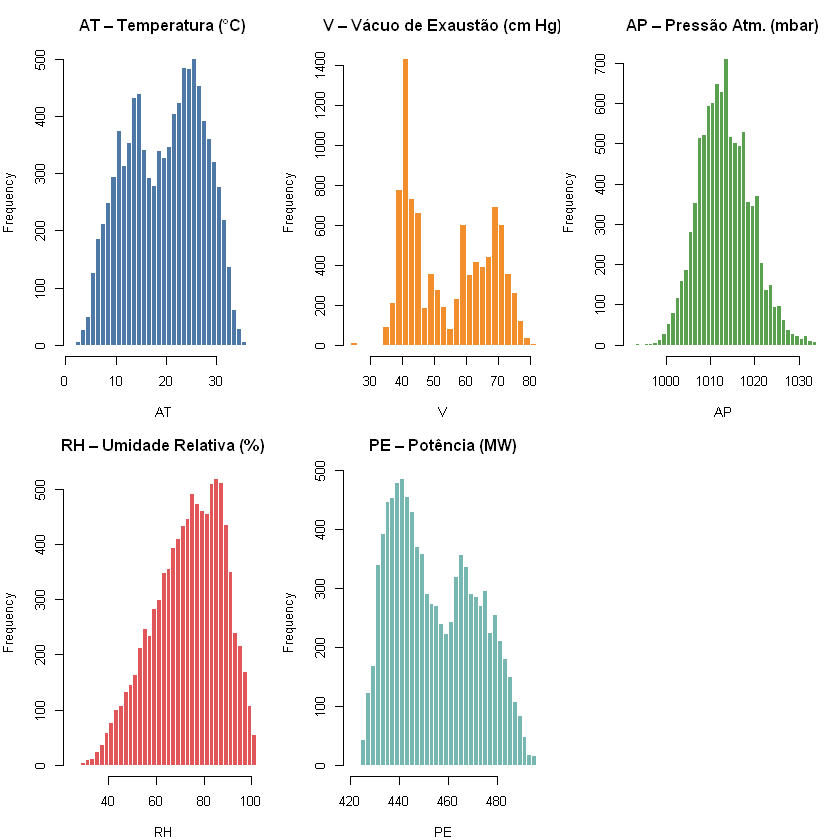

In [7]:
# Histogramas de todas as variáveis
par(mfrow = c(2, 3), mar = c(4, 4, 3, 1))

variaveis <- names(dados)
titulos   <- c("AT – Temperatura (°C)", "V – Vácuo de Exaustão (cm Hg)",
               "AP – Pressão Atm. (mbar)", "RH – Umidade Relativa (%)",
               "PE – Potência (MW)")
cores     <- c("#4E79A7", "#F28E2B", "#59A14F", "#E15759", "#76B7B2")

for (i in seq_along(variaveis)) {
  hist(dados[[variaveis[i]]],
       main  = titulos[i],
       xlab  = variaveis[i],
       col   = cores[i],
       border = "white",
       breaks = 40)
}

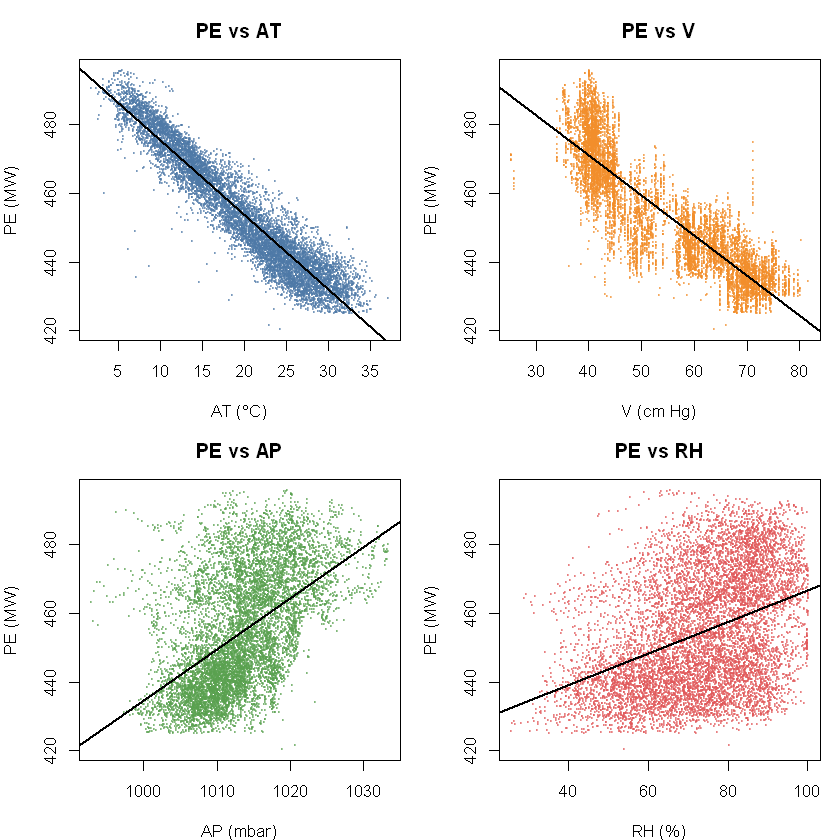

In [8]:
# Diagramas de dispersão: cada covariável vs PE
par(mfrow = c(2, 2), mar = c(4, 4, 3, 1))

covs   <- c("AT", "V", "AP", "RH")
xlabel <- c("AT (°C)", "V (cm Hg)", "AP (mbar)", "RH (%)")
cores2 <- c("#4E79A7", "#F28E2B", "#59A14F", "#E15759")

for (i in seq_along(covs)) {
  plot(dados[[covs[i]]], dados$PE,
       xlab = xlabel[i], ylab = "PE (MW)",
       main = paste("PE vs", covs[i]),
       pch  = 20, cex = 0.3,
       col  = adjustcolor(cores2[i], alpha.f = 0.5))
  abline(lm(PE ~ dados[[covs[i]]], data = dados),
         col = "black", lwd = 2)
}

---
## 4. Modelo de Regressão Linear

### 4.1 Notação e Definições

Seja $i = 1, 2, \ldots, n$ o índice da observação, com $n = 9568$. Definimos as seguintes quantidades para a $i$-ésima observação:

- $Y_i$: produção líquida de energia (MW)
- $x_{i1}$: temperatura ambiente $AT_i$ (°C)
- $x_{i2}$: vácuo de exaustão $V_i$ (cm Hg)
- $x_{i3}$: pressão ambiente $AP_i$ (mbar)
- $x_{i4}$: umidade relativa $RH_i$ (%)

### 4.2 Especificação Escalar

O modelo de regressão linear múltipla é:

$$Y_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \beta_3 x_{i3} + \beta_4 x_{i4} + \varepsilon_i, \quad i = 1, \ldots, n$$

onde:

- $\beta_0$: intercepto — produção esperada quando todas as covariáveis são zero
- $\beta_1$: variação esperada em PE para cada aumento de 1°C em temperatura
- $\beta_2$: variação esperada em PE para cada aumento de 1 cm Hg no vácuo
- $\beta_3$: variação esperada em PE para cada aumento de 1 mbar na pressão
- $\beta_4$: variação esperada em PE para cada aumento de 1 pp na umidade relativa
- $\varepsilon_i$: erro aleatório da $i$-ésima observação

### 4.3 Especificação Matricial

Definindo:

$$\mathbf{Y}_{n \times 1} = (Y_1, \ldots, Y_n)^\top, \quad \boldsymbol{\beta}_{p \times 1} = (\beta_0, \beta_1, \beta_2, \beta_3, \beta_4)^\top$$

$$X_{n \times p} = \begin{pmatrix} 1 & x_{11} & x_{12} & x_{13} & x_{14} \\ \vdots & \vdots & \vdots & \vdots & \vdots \\ 1 & x_{n1} & x_{n2} & x_{n3} & x_{n4} \end{pmatrix}$$

com $p = 5$ (intercepto + 4 covariáveis), o modelo escreve-se compactamente como:

$$\mathbf{Y} = X\boldsymbol{\beta} + \boldsymbol{\varepsilon}$$

### 4.4 Distribuição dos Erros e Verossimilhança

Assumindo erros independentes e normalmente distribuídos:

$$\boldsymbol{\varepsilon} \sim \mathcal{N}_n(\mathbf{0}_n,\, \sigma^2 I_n), \quad \sigma^2 > 0$$

a verossimilhança é:

$$L(\boldsymbol{\beta}, \sigma^2) \propto (\sigma^2)^{-n/2} \exp\!\left(-\frac{(\mathbf{Y} - X\boldsymbol{\beta})^\top(\mathbf{Y} - X\boldsymbol{\beta})}{2\sigma^2}\right)$$

In [9]:
# Construção explícita das matrizes X e Y
Y <- as.matrix(dados$PE)                     # vetor resposta n×1
X <- cbind(1, as.matrix(dados[, c("AT","V","AP","RH")]))  # matriz design n×5
colnames(X) <- c("Intercept", "AT", "V", "AP", "RH")

n <- nrow(X)   # número de observações
p <- ncol(X)   # número de parâmetros (intercepto + 4 covariáveis)

cat("Dimensões de X:", n, "×", p, "\n")
cat("Dimensões de Y:", n, "× 1\n")
cat("Primeiras 3 linhas de X:\n")
print(head(X, 3))

Dimensões de X: 9568 × 5 
Dimensões de Y: 9568 × 1
Primeiras 3 linhas de X:
     Intercept    AT     V      AP    RH
[1,]         1 14.96 41.76 1024.07 73.17
[2,]         1 25.18 62.96 1020.04 59.08
[3,]         1  5.11 39.40 1012.16 92.14


---
## 5. Especificação Bayesiana e Escolha dos Hiperparâmetros

Adotamos o prior conjugado:

$$\sigma^2 \sim \text{IG}(a_0, b_0)$$

$$\boldsymbol{\beta} \mid \sigma^2 \sim \mathcal{N}_p(\boldsymbol{\mu}_0,\; \sigma^2 \Lambda_0^{-1})$$

de forma que $(\boldsymbol{\beta}, \sigma^2) \sim \mathcal{NIG}(\boldsymbol{\mu}_0, \Lambda_0, a_0, b_0)$.

**Escolha dos hiperparâmetros (prior fraco/não-informativo):**

$$\boldsymbol{\mu}_0 = \mathbf{0}_5, \quad \Lambda_0 = 10^{-4} \cdot I_5, \quad a_0 = b_0 = 0.01$$

Valores pequenos de $\Lambda_0$ refletem grande incerteza *a priori* sobre os coeficientes (prior difuso). Com $a_0 = b_0 = 0.01$, a distribuição IG *a priori* da variância é também pouco informativa.

In [10]:
# ── Hiperparâmetros a priori ───────────────────────────────────────────────
mu_0    <- matrix(0, nrow = p, ncol = 1)   # média a priori: vetor zero p×1
Lambda_0 <- 1e-4 * diag(p)                 # precisão a priori: prior fraco
a_0     <- 0.01                            # hiperparâmetro da IG
b_0     <- 0.01                            # hiperparâmetro da IG

cat("mu_0 (transposto):", t(mu_0), "\n")
cat("Lambda_0 (diagonal):", diag(Lambda_0), "\n")
cat("a_0 =", a_0, " | b_0 =", b_0, "\n")

mu_0 (transposto): 0 0 0 0 0 
Lambda_0 (diagonal): 1e-04 1e-04 1e-04 1e-04 1e-04 
a_0 = 0.01  | b_0 = 0.01 


---
## 6. Atualização Bayesiana: Cálculo da Posterior

A posterior conjunta tem forma fechada:

$$(\boldsymbol{\beta}, \sigma^2 \mid \mathbf{Y}, X) \sim \mathcal{NIG}(\boldsymbol{\mu}_n, \Lambda_n, a_n, b_n)$$

com hiperparâmetros atualizados:

$$\Lambda_n = \Lambda_0 + X^\top X$$

$$\boldsymbol{\mu}_n = \Lambda_n^{-1}(\Lambda_0 \boldsymbol{\mu}_0 + X^\top \mathbf{Y})$$

$$a_n = a_0 + \frac{n}{2}$$

$$b_n = b_0 + \frac{1}{2}\left(\mathbf{Y}^\top \mathbf{Y} + \boldsymbol{\mu}_0^\top \Lambda_0 \boldsymbol{\mu}_0 - \boldsymbol{\mu}_n^\top \Lambda_n \boldsymbol{\mu}_n\right)$$

In [11]:
# ── Atualização Bayesiana (forma analítica fechada) ────────────────────────

# Precisão posterior: Lambda_n = Lambda_0 + X'X
Lambda_n <- Lambda_0 + t(X) %*% X

# Média posterior: mu_n = Lambda_n^{-1} (Lambda_0 mu_0 + X'Y)
Lambda_n_inv <- solve(Lambda_n)
mu_n <- Lambda_n_inv %*% (Lambda_0 %*% mu_0 + t(X) %*% Y)

# Hiperparâmetros da IG posterior
a_n <- a_0 + n / 2
b_n <- b_0 + 0.5 * (t(Y) %*% Y +
                     t(mu_0) %*% Lambda_0 %*% mu_0 -
                     t(mu_n) %*% Lambda_n  %*% mu_n)
b_n <- as.numeric(b_n)

cat("=== Hiperparâmetros Posteriores ===\n")
cat("a_n =", a_n, "\n")
cat("b_n =", round(b_n, 4), "\n")
cat("\nMédia posterior dos coeficientes (mu_n):\n")
rownames(mu_n) <- c("Intercepto", "beta_AT", "beta_V", "beta_AP", "beta_RH")
print(round(mu_n, 6))

=== Hiperparâmetros Posteriores ===
a_n = 4784.01 
b_n = 99361.57 

Média posterior dos coeficientes (mu_n):
                 [,1]
Intercepto 454.401444
beta_AT     -1.977376
beta_V      -0.233934
beta_AP      0.062284
beta_RH     -0.158028


In [12]:
# ── Variância posterior de sigma² e dos coeficientes ──────────────────────

# E[sigma²|Y] = b_n / (a_n - 1)  (para a_n > 1)
E_sigma2 <- b_n / (a_n - 1)
cat("E[sigma² | Y] =", round(E_sigma2, 4), "\n")
cat("DP residual estimado (sqrt) =", round(sqrt(E_sigma2), 4), "\n")

# Matriz de covariância posterior de beta | sigma², Y  (com sigma² = E[sigma²])
Cov_beta_post <- E_sigma2 * Lambda_n_inv
DP_beta <- sqrt(diag(Cov_beta_post))
names(DP_beta) <- c("Intercepto", "beta_AT", "beta_V", "beta_AP", "beta_RH")

cat("\nDesvios-padrão posteriores marginais dos coeficientes:\n")
print(round(DP_beta, 6))

E[sigma² | Y] = 20.7739 
DP residual estimado (sqrt) = 4.5578 

Desvios-padrão posteriores marginais dos coeficientes:
Intercepto    beta_AT     beta_V    beta_AP    beta_RH 
  9.745252   0.015287   0.007281   0.009455   0.004168 


In [13]:
# ── Tabela resumo da posterior ─────────────────────────────────────────────
coef_names <- c("Intercepto (beta_0)", "AT (beta_1)", "V (beta_2)",
                "AP (beta_3)", "RH (beta_4)")

# Intervalos de credibilidade de 95% marginais  (t-Student com 2*a_n g.l.)
# beta_j | Y  ~ t_{2a_n}(mu_n_j, b_n/a_n * [Lambda_n^{-1}]_{jj})
gl   <- 2 * a_n
escala <- sqrt(b_n / a_n * diag(Lambda_n_inv))
IC_low  <- mu_n - qt(0.975, df = gl) * escala
IC_high <- mu_n + qt(0.975, df = gl) * escala

tabela_post <- data.frame(
  Parametro   = coef_names,
  Media_Post  = round(mu_n, 5),
  DP_Post     = round(DP_beta, 5),
  IC95_Low    = round(IC_low, 5),
  IC95_High   = round(IC_high, 5)
)
rownames(tabela_post) <- NULL

cat("=== Resumo da Distribuição Posterior dos Coeficientes ===\n")
print(tabela_post)

=== Resumo da Distribuição Posterior dos Coeficientes ===
            Parametro Media_Post DP_Post  IC95_Low IC95_High
1 Intercepto (beta_0)  454.40144 9.74525 435.30068 473.50221
2         AT (beta_1)   -1.97738 0.01529  -2.00734  -1.94741
3          V (beta_2)   -0.23393 0.00728  -0.24821  -0.21966
4         AP (beta_3)    0.06228 0.00945   0.04375   0.08082
5         RH (beta_4)   -0.15803 0.00417  -0.16620  -0.14986


**Interpretação dos coeficientes posteriores:**

- **$\beta_1$ (AT)**: coeficiente negativo — temperaturas mais altas reduzem a eficiência das turbinas a gás, diminuindo a potência produzida.
- **$\beta_2$ (V)**: coeficiente negativo — maior vácuo de exaustão (pressão mais baixa no condensador) reduz a eficiência da turbina a vapor.
- **$\beta_3$ (AP)**: coeficiente positivo — maior pressão atmosférica favorece a densidade do ar nas turbinas a gás.
- **$\beta_4$ (RH)**: coeficiente ligeiramente negativo — umidade mais alta pode reduzir levemente o desempenho.

---
## 7. Comparação com MQO (Mínimos Quadrados Ordinários)

Com prior não-informativo ($\Lambda_0 \to 0$), a média posterior $\boldsymbol{\mu}_n$ deve convergir para o estimador MQO $\hat{\boldsymbol{\beta}} = (X^\top X)^{-1} X^\top \mathbf{Y}$. Verificamos isso abaixo.

In [14]:
# Estimador MQO clássico via lm()
modelo_ols <- lm(PE ~ AT + V + AP + RH, data = dados)

cat("=== Comparação: MQO vs Bayesiano (prior fraco) ===\n\n")
comparacao <- data.frame(
  Parametro = c("Intercepto", "AT", "V", "AP", "RH"),
  OLS       = round(coef(modelo_ols), 6),
  Bayesiano = round(mu_n, 6)
)
rownames(comparacao) <- NULL
print(comparacao)

=== Comparação: MQO vs Bayesiano (prior fraco) ===

   Parametro        OLS  Bayesiano
1 Intercepto 454.609274 454.401444
2         AT  -1.977513  -1.977376
3          V  -0.233916  -0.233934
4         AP   0.062083   0.062284
5         RH  -0.158054  -0.158028


In [15]:
# Resumo completo do modelo OLS para referência
summary(modelo_ols)


Call:
lm(formula = PE ~ AT + V + AP + RH, data = dados)

Residuals:
    Min      1Q  Median      3Q     Max 
-43.435  -3.166  -0.118   3.201  17.778 

Coefficients:
              Estimate Std. Error  t value Pr(>|t|)    
(Intercept) 454.609274   9.748512   46.634  < 2e-16 ***
AT           -1.977513   0.015289 -129.342  < 2e-16 ***
V            -0.233916   0.007282  -32.122  < 2e-16 ***
AP            0.062083   0.009458    6.564 5.51e-11 ***
RH           -0.158054   0.004168  -37.918  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 4.558 on 9563 degrees of freedom
Multiple R-squared:  0.9287,	Adjusted R-squared:  0.9287 
F-statistic: 3.114e+04 on 4 and 9563 DF,  p-value: < 2.2e-16


Como esperado, com o prior praticamente não-informativo ($\Lambda_0 = 10^{-4} I$), as estimativas bayesianas são praticamente idênticas às do MQO. A diferença fundamental está na **interpretação**: no arcabouço bayesiano, $\boldsymbol{\mu}_n$ é a média de uma distribuição de probabilidade sobre os coeficientes, e os intervalos de credibilidade têm interpretação probabilística direta.

---
## 8. Análise de Resíduos

Verificamos os resíduos do ajuste para checar a adequação do modelo (normalidade, homocedasticidade, ausência de padrões).

In [16]:
# Valores ajustados e resíduos (usando média posterior dos coeficientes)
Y_hat    <- X %*% mu_n
residuos <- Y - Y_hat

cat("R² (coeficiente de determinação):",
    round(1 - sum(residuos^2) / sum((Y - mean(Y))^2), 5), "\n")
cat("RMSE:", round(sqrt(mean(residuos^2)), 4), "MW\n")
cat("MAE: ", round(mean(abs(residuos)),  4), "MW\n")

R² (coeficiente de determinação): 0.9287 
RMSE: 4.5571 MW
MAE:  3.6252 MW


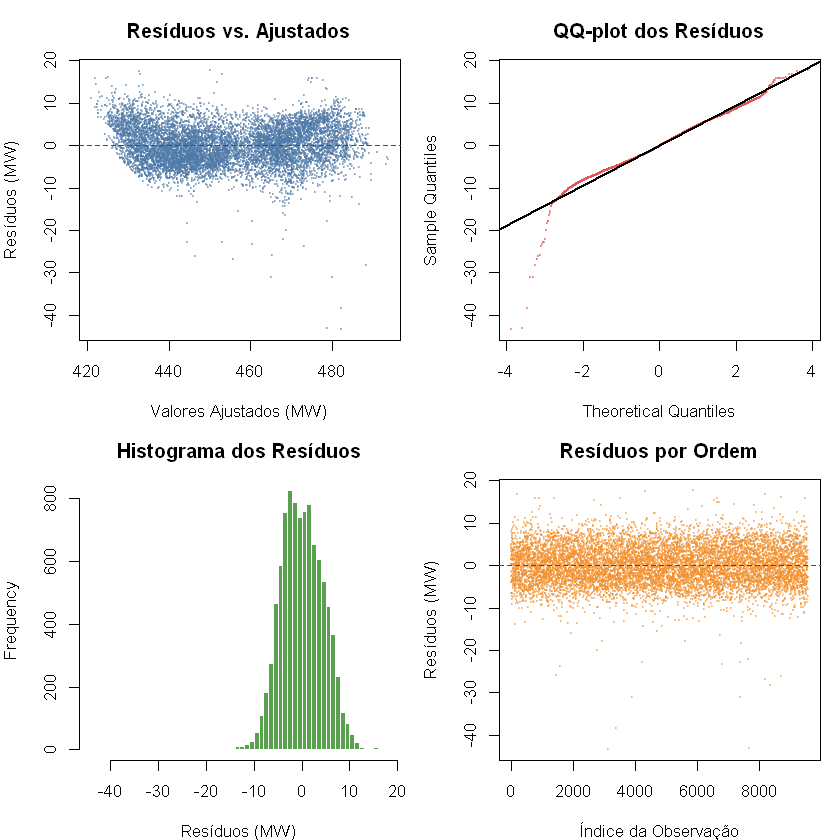

In [17]:
# Gráficos de diagnóstico dos resíduos
par(mfrow = c(2, 2), mar = c(4, 4, 3, 1))

# 1. Resíduos vs Valores ajustados
plot(Y_hat, residuos,
     xlab = "Valores Ajustados (MW)", ylab = "Resíduos (MW)",
     main = "Resíduos vs. Ajustados",
     pch = 20, cex = 0.3,
     col = adjustcolor("#4E79A7", alpha.f = 0.4))
abline(h = 0, col = "red", lwd = 1.5, lty = 2)

# 2. QQ-plot dos resíduos
qqnorm(residuos, main = "QQ-plot dos Resíduos",
       pch = 20, cex = 0.3,
       col = adjustcolor("#E15759", alpha.f = 0.5))
qqline(residuos, col = "black", lwd = 2)

# 3. Histograma dos resíduos
hist(residuos,
     breaks = 50,
     main   = "Histograma dos Resíduos",
     xlab   = "Resíduos (MW)",
     col    = "#59A14F", border = "white")

# 4. Resíduos ao longo do tempo (ordem das observações)
plot(seq_along(residuos), residuos,
     type = "p", pch = 20, cex = 0.2,
     col  = adjustcolor("#F28E2B", alpha.f = 0.4),
     xlab = "Índice da Observação", ylab = "Resíduos (MW)",
     main = "Resíduos por Ordem")
abline(h = 0, col = "red", lwd = 1.5, lty = 2)

---
## 9. Distribuições Posteriores Marginais dos Coeficientes

A distribuição marginal de cada coeficiente $\beta_j \mid \mathbf{Y}$ segue uma distribuição $t$-Student com $2a_n$ graus de liberdade:

$$\beta_j \mid \mathbf{Y} \sim t_{2a_n}\!\left(\mu_{n,j},\; \frac{b_n}{a_n}[\Lambda_n^{-1}]_{jj}\right)$$

Como $n = 9568$ é muito grande, essa distribuição é essencialmente normal. Visualizamos as densidades marginais abaixo.

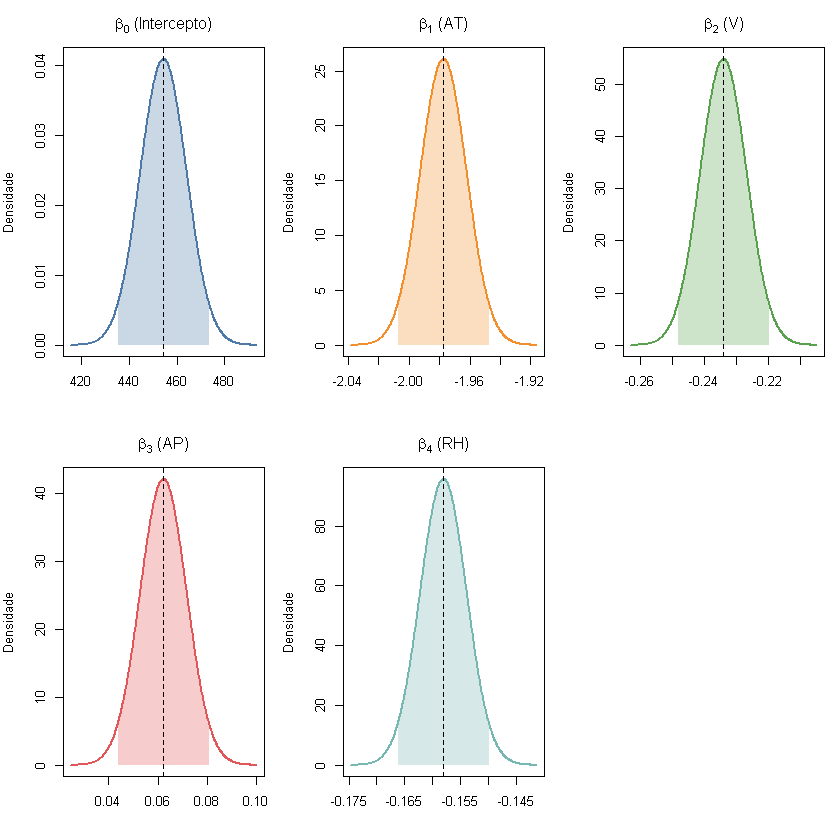

In [18]:
# Densidades marginais posteriores de cada coeficiente
par(mfrow = c(2, 3), mar = c(4, 4, 3, 1))

nomes_plot <- c(expression(beta[0]~"(Intercepto)"),
                expression(beta[1]~"(AT)"),
                expression(beta[2]~"(V)"),
                expression(beta[3]~"(AP)"),
                expression(beta[4]~"(RH)"))

for (j in 1:p) {
  centro <- mu_n[j]
  esc    <- sqrt(b_n / a_n * Lambda_n_inv[j, j])
  gl_t   <- 2 * a_n

  # grade de pontos para a densidade
  xlim_range <- centro + c(-4, 4) * esc
  xs <- seq(xlim_range[1], xlim_range[2], length.out = 500)
  ys <- dt((xs - centro) / esc, df = gl_t) / esc

  plot(xs, ys, type = "l", lwd = 2, col = cores[j],
       xlab = "", ylab = "Densidade",
       main = nomes_plot[[j]])

  # IC 95%
  ic_l <- IC_low[j]
  ic_h <- IC_high[j]
  xs_shade <- xs[xs >= ic_l & xs <= ic_h]
  ys_shade <- ys[xs >= ic_l & xs <= ic_h]
  polygon(c(xs_shade[1], xs_shade, xs_shade[length(xs_shade)]),
          c(0, ys_shade, 0),
          col = adjustcolor(cores[j], alpha.f = 0.3), border = NA)
  abline(v = centro, col = "black", lwd = 1.5, lty = 2)
}

As regiões sombreadas representam os **intervalos de credibilidade de 95%**. A linha tracejada indica a média posterior $\mu_{n,j}$ de cada coeficiente.

---
## 10. Predição

Para uma nova observação $\mathbf{x}_\star$, a **distribuição preditiva posterior** marginaliza sobre $\boldsymbol{\beta}$ e $\sigma^2$, resultando em:

$$Y_\star \mid \mathbf{Y} \sim t_{2a_n}\!\left(\mathbf{x}_\star^\top \boldsymbol{\mu}_n,\; \frac{b_n}{a_n}\left(1 + \mathbf{x}_\star^\top \Lambda_n^{-1} \mathbf{x}_\star\right)\right)$$

In [19]:
# Função de predição com intervalo de credibilidade
predicao_bayesiana <- function(x_new, mu_n, Lambda_n_inv, a_n, b_n, nivel = 0.95) {
  # x_new: vetor de covariáveis SEM intercepto (c(AT, V, AP, RH))
  x_star <- matrix(c(1, x_new), ncol = 1)      # adiciona intercepto
  
  media_pred  <- as.numeric(t(x_star) %*% mu_n)
  escala_pred <- sqrt(as.numeric(b_n / a_n * (1 + t(x_star) %*% Lambda_n_inv %*% x_star)))
  gl_pred     <- 2 * a_n
  alpha       <- 1 - nivel
  
  ic_l <- media_pred - qt(1 - alpha / 2, df = gl_pred) * escala_pred
  ic_h <- media_pred + qt(1 - alpha / 2, df = gl_pred) * escala_pred
  
  list(media = media_pred, IC_low = ic_l, IC_high = ic_h)
}

# Exemplo: nova observação com AT=20, V=55, AP=1010, RH=70
nova_obs <- c(AT = 20, V = 55, AP = 1010, RH = 70)
pred <- predicao_bayesiana(nova_obs, mu_n, Lambda_n_inv, a_n, b_n)

cat("=== Predição Bayesiana para nova observação ===\n")
cat("Covariáveis: AT =", nova_obs["AT"], "| V =", nova_obs["V"],
    "| AP =", nova_obs["AP"], "| RH =", nova_obs["RH"], "\n")
cat("Predição (média)        :", round(pred$media, 3), "MW\n")
cat("IC 95% de credibilidade : [", round(pred$IC_low, 3), ",",
    round(pred$IC_high, 3), "] MW\n")

=== Predição Bayesiana para nova observação ===
Covariáveis: AT = 20 | V = 55 | AP = 1010 | RH = 70 
Predição (média)        : 453.833 MW
IC 95% de credibilidade : [ 444.899 , 462.767 ] MW


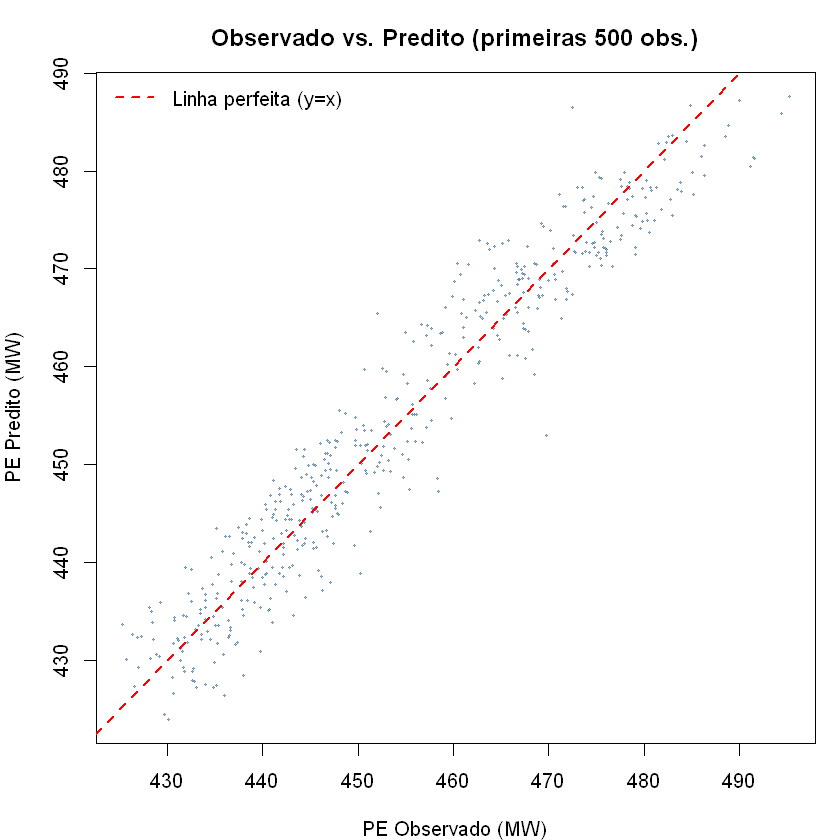

In [20]:
# Avaliação preditiva: predições vs valores observados (primeiras 500 obs.)
idx_aval <- 1:500
Y_pred_med <- as.numeric(X[idx_aval, ] %*% mu_n)

par(mfrow = c(1, 1), mar = c(4, 4, 3, 1))
plot(Y[idx_aval], Y_pred_med,
     xlab = "PE Observado (MW)", ylab = "PE Predito (MW)",
     main = "Observado vs. Predito (primeiras 500 obs.)",
     pch = 20, cex = 0.5,
     col = adjustcolor("#4E79A7", alpha.f = 0.6))
abline(0, 1, col = "red", lwd = 2, lty = 2)
legend("topleft", legend = "Linha perfeita (y=x)",
       col = "red", lty = 2, lwd = 2, bty = "n")

---
## 11. Sumário Final

Este notebook implementou, passo a passo, a **regressão linear bayesiana com prior conjugado Normal–Gama Inversa** aplicada ao dataset *Combined Cycle Power Plant*.

**Principais resultados:**

| Etapa | O que foi feito |
|---|---|
| Seção 2 | Carregamento e inspeção dos dados (9568 obs., 5 variáveis) |
| Seção 3 | Análise descritiva, correlações e diagramas de dispersão |
| Seções 4–5 | Construção das matrizes $X$, $\mathbf{Y}$ e escolha dos hiperparâmetros |
| Seção 6 | Atualização analítica: $\Lambda_n$, $\boldsymbol{\mu}_n$, $a_n$, $b_n$ |
| Seção 7 | Verificação: posterior ≈ MQO sob prior fraco |
| Seção 8 | Diagnóstico de resíduos (normalidade, homocedasticidade) |
| Seção 9 | Densidades marginais posteriores + intervalos de credibilidade 95% |
| Seção 10 | Distribuição preditiva posterior e avaliação preditiva |

**Sobre a escolha do prior:** com $\Lambda_0 = 10^{-4} I$ e $a_0 = b_0 = 0.01$, o prior é praticamente não-informativo e os resultados bayesianos coincidem com os do MQO clássico. O diferencial do arcabouço bayesiano está na **interpretação probabilística** completa — os intervalos de credibilidade têm significado probabilístico direto e a distribuição preditiva propaga naturalmente toda a incerteza dos parâmetros.